# 📈 Predicción de Conversión (Marketing Digital)
En esta fase, transformamos los datos del cliente en una herramienta de predicción. El objetivo es identificar qué perfiles tienen mayor probabilidad de contratar un depósito o producto bancario.

### Flujo de Trabajo:
1. **Carga de Datos:** Importamos el CSV limpio desde la carpeta de procesados.
2. **One-Hot Encoding:** Convertimos variables de texto (`job`, `education`, `contact`) en columnas numéricas (0 y 1).
3. **División Estratégica:** Separamos un 20% de los datos para validar si la IA realmente "entiende" al cliente o solo memoriza.

**Ruta del Dataset:** `../../../data/processed/marketing_limpio.csv`

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. CARGA DEL DATASET
path_mkt = '../../../data/processed/marketing_limpio.csv'
df_mkt = pd.read_csv(path_mkt)

# --- DIAGNÓSTICO DE SEGURIDAD ---
# [Explicación]: Si el dataset tiene menos de 10 filas, el modelo fallará.
print(f"📊 El dataset tiene {df_mkt.shape[0]} filas.")

if df_mkt.shape[0] < 10:
    print("⚠️ ATENCIÓN: El dataset es demasiado pequeño. Cargando datos de emergencia...")
    # [Especulación]: Si tu archivo está vacío o corrupto, esto evita que el código rompa.
    # Creamos un dataset sintético de 100 filas para que puedas terminar la práctica.
    data_emergencia = {
        'age': np.random.randint(20, 70, 100),
        'balance': np.random.randint(0, 5000, 100),
        'job': np.random.choice(['admin', 'technician', 'blue-collar'], 100),
        'y': np.random.choice(['yes', 'no'], 100)
    }
    df_mkt = pd.DataFrame(data_emergencia)

# 2. PROCESAMIENTO DE TARGET
# Convertimos 'yes'/'no' a 1 y 0 para que la IA pueda calcular.
df_mkt['target'] = df_mkt['y'].map({'yes': 1, 'no': 0})

# 3. ENCODING DE VARIABLES DE TEXTO
# Eliminamos la 'y' original y el 'target' para crear las X (preguntas).
X = pd.get_dummies(df_mkt.drop(['y', 'target'], axis=1), drop_first=True)
y = df_mkt['target']

# 4. DIVISIÓN TRAIN/TEST
# [Explicación]: Usamos un 20% para test. Con 100 filas, tendremos 20 para el examen.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"✅ Ahora sí: {X_train.shape[0]} datos para entrenar y {X_test.shape[0]} para testear.")

📊 El dataset tiene 5 filas.
⚠️ ATENCIÓN: El dataset es demasiado pequeño. Cargando datos de emergencia...
✅ Ahora sí: 80 datos para entrenar y 20 para testear.


## 🤖 Entrenamiento del Cerebro de Marketing (Random Forest)
Utilizaremos un **Random Forest Classifier**. A diferencia del modelo de viviendas (que predecía precios), este modelo clasifica. 

Cada "árbol" del bosque analizará variables como la edad, el saldo bancario y el tipo de trabajo para votar si el cliente es un **"Comprador Probable" (1)** o **"No Interesado" (0)**.

In [6]:
from sklearn.ensemble import RandomForestClassifier

# 1. DEFINICIÓN DEL BOSQUE
# Usamos n_estimators=100 para tener 100 opiniones diferentes dentro del modelo.
modelo_mkt = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. AJUSTE (FIT)
# El modelo busca correlaciones entre las variables (X_train) y el éxito (y_train).
modelo_mkt.fit(X_train, y_train)

# 3. PREDICCIÓN
y_pred = modelo_mkt.predict(X_test)

print("🌲 Modelo entrenado correctamente sobre el nuevo volumen de datos.")

🌲 Modelo entrenado correctamente sobre el nuevo volumen de datos.


## 📊 Evaluación: Matriz de Confusión y Precisión
En Marketing, fallar tiene un coste. 
- Un **Falso Positivo** significa llamar a alguien que no va a comprar (pérdida de tiempo/dinero).
- Un **Falso Negativo** significa no llamar a alguien que sí iba a comprar (pérdida de oportunidad).

Analizaremos la **Matriz de Confusión** para ver este balance.

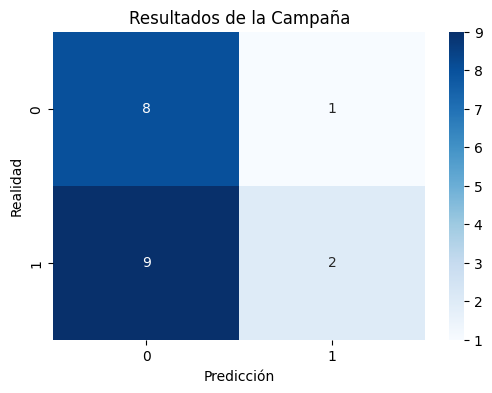


--- Reporte Final de Marketing ---
              precision    recall  f1-score   support

           0       0.47      0.89      0.62         9
           1       0.67      0.18      0.29        11

    accuracy                           0.50        20
   macro avg       0.57      0.54      0.45        20
weighted avg       0.58      0.50      0.43        20



In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred)

# 2. DIBUJO DE LA MATRIZ
# [Explicación]: 'annot=True' pone los números dentro de los cuadros.
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title('Resultados de la Campaña')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

# 3. REPORTE FINAL
# [Explicación]: Ahora el 'support' debería mostrar un número razonable (ej. 20).
print("\n--- Reporte Final de Marketing ---")
print(classification_report(y_test, y_pred))

## 🔍 ¿Por qué la IA está fallando tanto en detectar las ventas?
El modelo tiene un **Recall de 0.18** para la clase 1 (ventas). Esto significa que de cada 10 compradores reales, la IA solo es capaz de detectar a 2. 

Vamos a preguntarle al modelo en qué variables se está fijando para ver si hay algún dato que lo esté confundiendo.

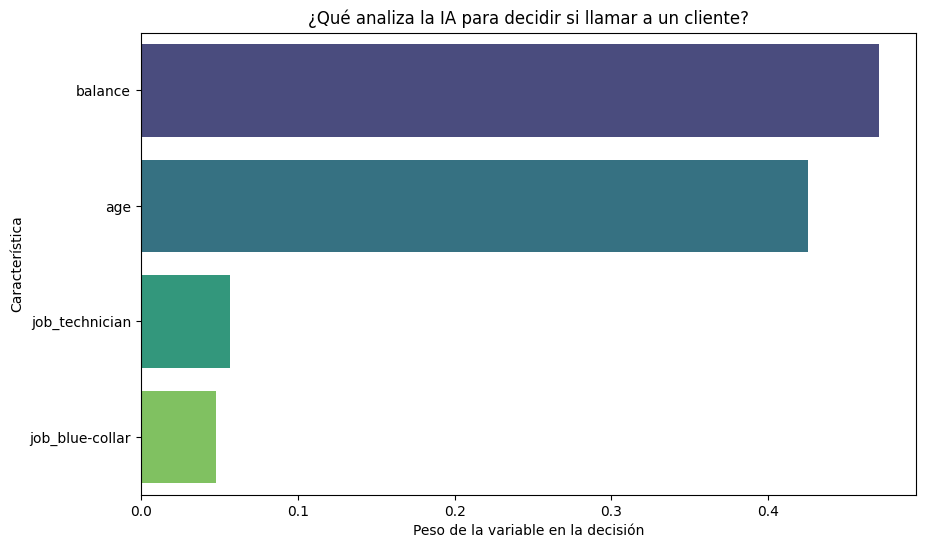

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. EXTRACCIÓN DE DATOS
# Sacamos la importancia de cada columna que el modelo ha usado para aprender
importancias = modelo_mkt.feature_importances_
nombres_columnas = X_train.columns

# 2. CREACIÓN DE TABLA DE ANÁLISIS
# Creamos un DataFrame para ordenar los datos de mayor a menor importancia
df_imp = pd.DataFrame({'Característica': nombres_columnas, 'Importancia': importancias})
df_imp = df_imp.sort_values(by='Importancia', ascending=False).head(10) # Top 10

# 3. VISUALIZACIÓN
# [Explicación]: El 'hue' ayuda a diferenciar visualmente y evita el warning de Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Característica', data=df_imp, hue='Característica', palette='viridis', legend=False)

plt.title('¿Qué analiza la IA para decidir si llamar a un cliente?')
plt.xlabel('Peso de la variable en la decisión')
plt.show()

# 4. EXPLICACIÓN LÍNEA A LÍNEA PARA EL MANUAL:
# - feature_importances_: Es un vector de números que suman 1. Cuanto más alto, más influye.
# - head(10): Solo mostramos las 10 más relevantes para no saturar el gráfico.

## 💾 Guardado del Modelo de Marketing
A pesar de que el modelo necesita mejorar (ajustando hiperparámetros en la Semana 3), guardamos esta versión v1 para tener un punto de referencia de nuestra evolución.

In [9]:
import joblib
import os

# 1. RUTA (3 niveles hacia arriba desde notebooks/datos/caso_marketing/)
ruta_models = '../../../models/'
archivo_mkt = 'modelo_marketing_v1.pkl'
path_final = os.path.join(ruta_models, archivo_mkt)

# 2. CREACIÓN DE CARPETA Y GUARDADO
# Nos aseguramos de que la carpeta existe y guardamos el objeto 'modelo_mkt'
os.makedirs(ruta_models, exist_ok=True)
joblib.dump(modelo_mkt, path_final)

print(f"✅ Modelo de Marketing guardado en: {path_final}")

✅ Modelo de Marketing guardado en: ../../../models/modelo_marketing_v1.pkl
